# Proposed Observation Layer for the DCM

**Purpose:** Show what the current expert-observation layer does, propose a replacement, and demonstrate it works on synthetic data.

**Summary:** The current DCM collapses all expert judgements into a single random binary draw. This notebook proposes replacing it with an ordered probit observation model that uses each expert's rating individually, and demonstrates parameter recovery on both a standalone leaf and a mini DCM tree.

In [1]:
import pytensor

pytensor.config.gcc__cxxflags = "-fbracket-depth=4096"

import numpy as np
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.special import logsumexp

rng = np.random.default_rng(42)

---

## 1. The current observation layer

The current code in `dcm_model.py` (lines 304--306) does this for every indicator:

```python
obs_average = evidencer["observation_stats"][self.candidate_system]["average"]
binary_value = 0 if float(obs_average) < random.random() else 1
obs_list = [binary_value]
```

Then feeds a single `pm.Bernoulli(..., observed=binary_value)` into the model.

**What this loses:**
- Individual expert responses (all collapsed into one average)
- Expert-specific calibration (harsh vs generous raters)
- The continuous/ordinal structure of the original responses
- Reproducibility (the binary draw depends on `random.random()`)

In [2]:
# Concrete example (illustrative, based on GWT data structure)
# Indicator: "Activation Steering Effects", System: "2024 Leading Chat LLMs"
expert_names = ["Expert A", "Expert B", "Expert C"]
expert_values = [1.0, 0.7, 0.2]

# Current approach: average, then random threshold
avg = np.mean(expert_values)
print(f"Expert values:  {expert_values}")
print(f"Average:        {avg:.2f}")
print(f"Current model:  draws random.random(), observes 0 or 1")
print(f"                -> all expert variation discarded")

Expert values:  [1.0, 0.7, 0.2]
Average:        0.63
Current model:  draws random.random(), observes 0 or 1
                -> all expert variation discarded


---

## 2. Proposed replacement: ordered probit observation model

Each expert $e$ gives a rating $r_{eij} \in \{1, \ldots, 7\}$ for indicator $j$ on system $i$. The latent indicator state $z_{ij} \in \{0, 1\}$ is unknown.

$$r_{eij} \mid z_{ij} \sim \text{OrderedProbit}(\eta_{eij},\; \kappa), \qquad \eta_{eij} = b_e + a \cdot z_{ij}$$

$$P(r_{eij} = k \mid z_{ij}) = \Phi(\kappa_k - b_e - a \cdot z_{ij}) - \Phi(\kappa_{k-1} - b_e - a \cdot z_{ij})$$

| Parameter | Meaning | Constraint |
|---|---|---|
| $a$ | Discrimination: how much indicator presence shifts ratings | $a > 0$, shared across all indicators |
| $b_e$ | Expert location shift: larger $b_e$ = more generous ratings | $b_1 = 0$ (anchor), rest free |
| $\kappa_1 < \cdots < \kappa_6$ | Shared cutpoints partitioning the latent scale | Ordered, shared across all experts |
| $z_{ij}$ | Latent indicator state: is this indicator truly present? | Binary, marginalised out |

**Why these constraints:**
- Variance fixed to 1 (standard probit convention, anchors the scale)
- $b_1 = 0$ anchors the location
- Shared $a$ and shared $\kappa$: the current GWT data has 6 experts with almost no cross-system overlap, so expert-specific discrimination or cutpoints are not identifiable

---

## 3. The marginal leaf likelihood

The latent state $z_{ij}$ is not observed. The tree above provides a prior probability $q_{ij} = P(z_{ij} = 1)$. We marginalise:

$$P(\mathbf{r}_{ij} \mid q_{ij}, \theta) = (1 - q_{ij}) \prod_e P(r_{eij} \mid z=0, \theta) \;+\; q_{ij} \prod_e P(r_{eij} \mid z=1, \theta)$$

This is a two-component mixture with known mixing weight $q_{ij}$. Each component is a product of independent ordered probit likelihoods across experts.

In [3]:
def ordinal_probs(cutpoints: np.ndarray, eta: float = 0.0) -> np.ndarray:
    """Ordinal category probabilities (probit link)."""
    c_aug = np.concatenate([[-np.inf], cutpoints, [np.inf]])
    return np.diff(norm.cdf(c_aug - eta))


def leaf_log_lik(
    ratings: np.ndarray,
    q: float,
    a: float,
    b: np.ndarray,
    kappa: np.ndarray,
) -> float:
    """Log marginal likelihood for one leaf node.

    Parameters
    ----------
    ratings : (E,) array, observed ordinal ratings (0-indexed).
    q : prior P(z=1) from the tree above.
    a : discrimination (shared).
    b : (E,) expert biases.
    kappa : (K-1,) shared cutpoints.
    """
    log_components = np.zeros(2)
    for z in range(2):
        log_p_z = np.log(q if z == 1 else 1 - q)
        log_prod = 0.0
        for e in range(len(ratings)):
            eta = b[e] + a * z
            probs = ordinal_probs(kappa, eta=eta)
            log_prod += np.log(probs[ratings[e]] + 1e-30)
        log_components[z] = log_p_z + log_prod
    return logsumexp(log_components)

True z = 1, ratings = [6 5 6]


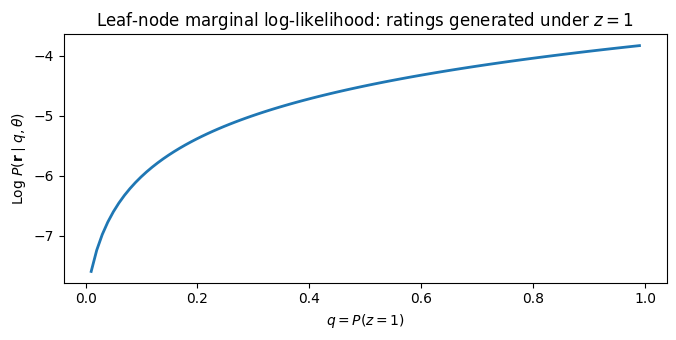

The likelihood increases with q, confirming the ratings
are more consistent with z=1 (indicator present).


In [4]:
# Numerical example: how do observed ratings shift the preferred q?
# We generate ratings under z=1. The likelihood should favour larger q,
# since the data are more consistent with indicator-present.
kappa_true = np.array([-1.5, -0.8, -0.1, 0.4, 1.0, 1.6])
a_true = 1.2
b_true = np.array([0.0, 0.3, -0.2])  # 3 experts, b_1 = 0
z_true = 1

# Generate one set of ratings under z=1
example_ratings = np.zeros(3, dtype=int)
for e in range(3):
    eta = b_true[e] + a_true * z_true
    probs = ordinal_probs(kappa_true, eta=eta)
    example_ratings[e] = rng.choice(len(probs), p=probs)

print(f"True z = {z_true}, ratings = {example_ratings}")

q_grid = np.linspace(0.01, 0.99, 100)
ll_grid = [leaf_log_lik(example_ratings, q, a_true, b_true, kappa_true) for q in q_grid]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(q_grid, ll_grid, lw=2)
ax.set_xlabel("$q = P(z=1)$")
ax.set_ylabel("Log $P(\\mathbf{r} \\mid q, \\theta)$")
ax.set_title("Leaf-node marginal log-likelihood: ratings generated under $z=1$")
plt.tight_layout()
plt.show()
print("The likelihood increases with q, confirming the ratings")
print("are more consistent with z=1 (indicator present).")

---

## 4. Parameter recovery: standalone leaf (known $z$)

First, verify the observation model in isolation. Generate synthetic data with known latent states and check that PyMC recovers $a$, $b_e$, and $\kappa$.

In [5]:
# Synthetic data: 3 experts, 20 indicators, 7-point scale, known z
n_experts = 3
n_indicators = 20
K = 7

true_a = 1.2
true_b = np.array([0.0, 0.4, -0.3])  # b_1 = 0 anchor
true_kappa = np.array([-1.5, -0.8, -0.1, 0.4, 1.0, 1.6])
true_z = rng.binomial(1, 0.5, size=n_indicators)

# Generate ratings
expert_idx_list, item_idx_list, rating_list = [], [], []
for e in range(n_experts):
    for j in range(n_indicators):
        eta = true_b[e] + true_a * true_z[j]
        probs = ordinal_probs(true_kappa, eta=eta)
        r = rng.choice(K, p=probs)
        expert_idx_list.append(e)
        item_idx_list.append(j)
        rating_list.append(r)

expert_idx = np.array(expert_idx_list)
item_idx = np.array(item_idx_list)
ratings = np.array(rating_list)

print(f"Observations: {len(ratings)}")
print(f"Latent states: {true_z}")

Observations: 60
Latent states: [1 0 1 1 1 0 0 0 1 1 1 0 0 1 0 1 1 1 0 1]


In [6]:
# Fit: ordered probit with known z
with pm.Model() as leaf_model:
    a = pm.HalfNormal("a", sigma=2.0)
    b_free = pm.Normal("b_free", mu=0.0, sigma=2.0, shape=n_experts - 1)
    b = pt.concatenate([pt.zeros(1), b_free])
    kappa = pm.Normal(
        "kappa",
        mu=0.0,
        sigma=2.0,
        shape=K - 1,
        transform=pm.distributions.transforms.ordered,
        initval=np.linspace(-1.5, 1.5, K - 1),
    )
    eta = b[expert_idx] + a * true_z[item_idx]
    pm.OrderedProbit("r", eta=eta, cutpoints=kappa, observed=ratings)

with leaf_model:
    idata_leaf = pm.sample(
        draws=1000, tune=1000, chains=4, random_seed=42, target_accept=0.95
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b_free, kappa]


/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.


In [7]:
# Recovery check
print("=== Discrimination ===")
print(f"  True: {true_a}")
print(f"  Post: {idata_leaf.posterior['a'].mean().item():.3f}")

print("\n=== Expert bias (free) ===")
print(f"  True: {true_b[1:]}")
b_post = idata_leaf.posterior["b_free"].mean(dim=("chain", "draw")).values
print(f"  Post: {np.round(b_post, 3)}")

print("\n=== Cutpoints ===")
print(f"  True: {true_kappa}")
k_post = idata_leaf.posterior["kappa"].mean(dim=("chain", "draw")).values
print(f"  Post: {np.round(k_post, 3)}")

az.summary(idata_leaf, var_names=["a", "b_free", "kappa"])

=== Discrimination ===
  True: 1.2
  Post: 1.482

=== Expert bias (free) ===
  True: [ 0.4 -0.3]
  Post: [ 0.34  -0.356]

=== Cutpoints ===
  True: [-1.5 -0.8 -0.1  0.4  1.   1.6]
  Post: [-1.591 -0.689 -0.205  0.496  1.164  1.933]


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,1.482,0.290,0.950,2.035,0.005,0.005,2851.0,1866.0,1.0
b_free[0],0.340,0.317,-0.232,0.941,0.005,0.005,3461.0,3035.0,1.0
b_free[1],-0.356,0.328,-0.975,0.241,0.006,0.005,3351.0,2832.0,1.0
kappa[0],-1.591,0.416,-2.347,-0.819,0.008,0.007,2738.0,2680.0,1.0
kappa[1],-0.689,0.313,-1.287,-0.120,0.005,0.004,3601.0,3298.0,1.0
kappa[2],-0.205,0.292,-0.747,0.357,0.005,0.004,3603.0,3078.0,1.0
kappa[3],0.496,0.287,-0.053,1.024,0.005,0.004,3432.0,2953.0,1.0
kappa[4],1.164,0.308,0.605,1.764,0.005,0.005,3171.0,2673.0,1.0
kappa[5],1.933,0.338,1.306,2.573,0.006,0.005,2962.0,2751.0,1.0


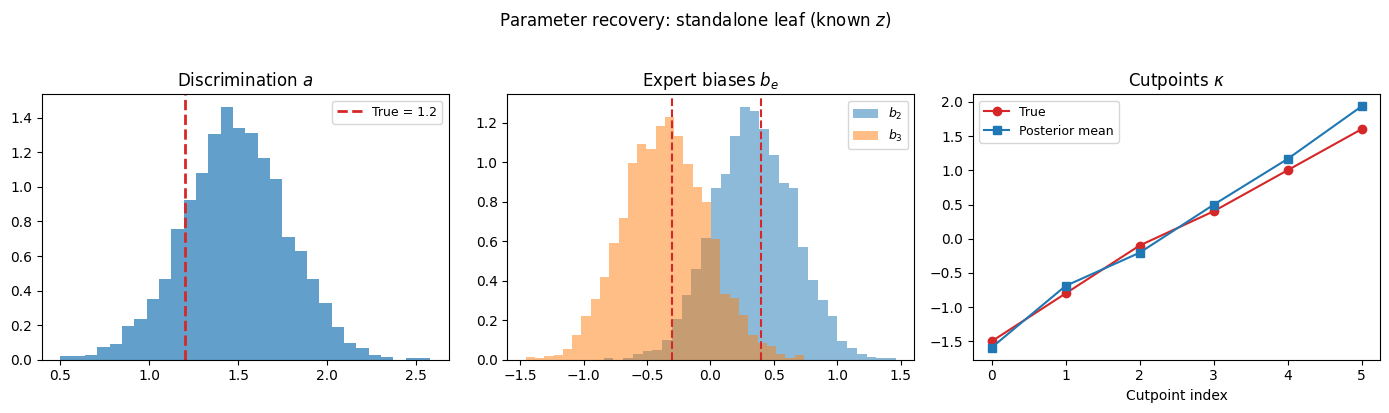

In [8]:
# Visual: posterior vs true
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# a
ax = axes[0]
a_draws = idata_leaf.posterior["a"].values.flatten()
ax.hist(a_draws, bins=30, density=True, alpha=0.7)
ax.axvline(true_a, color="C3", ls="--", lw=2, label=f"True = {true_a}")
ax.set_title("Discrimination $a$")
ax.legend(fontsize=9)

# b_free
ax = axes[1]
for i in range(n_experts - 1):
    draws = idata_leaf.posterior["b_free"].sel(b_free_dim_0=i).values.flatten()
    ax.hist(draws, bins=30, density=True, alpha=0.5, label=f"$b_{{{i + 2}}}$")
    ax.axvline(true_b[i + 1], color="C3", ls="--", lw=1.5)
ax.set_title("Expert biases $b_e$")
ax.legend(fontsize=9)

# kappa
ax = axes[2]
k_post_full = idata_leaf.posterior["kappa"].mean(dim=("chain", "draw")).values
ax.plot(true_kappa, "C3o-", label="True", ms=6)
ax.plot(k_post_full, "C0s-", label="Posterior mean", ms=6)
ax.set_xlabel("Cutpoint index")
ax.set_title("Cutpoints $\\kappa$")
ax.legend(fontsize=9)

plt.suptitle("Parameter recovery: standalone leaf (known $z$)", y=1.02)
plt.tight_layout()
plt.show()

---

## 5. Toy tree integration demo (unknown $z$)

This section demonstrates that the marginalised leaf likelihood can be embedded in a DCM-style hierarchy and that leaf evidence pushes posterior mass toward the correct latent states.

**Caveats:** This is a toy demo, not a full DCM replacement. The tree has only 4 indicators with 3 ratings each (12 total). Indicator states are deterministic given the parent feature (no indicator-level noise). Tree-level probabilities (e.g. `stance_p`) cannot be meaningfully recovered from a single realisation. The goal is to verify the machinery works, not to demonstrate precise parameter recovery.

**Mini tree structure:**
```
Stance (Beta prior -> Bernoulli)
  +-- Feature A (Beta-Bernoulli, conditional on stance)
  |     +-- Indicator A1 (ordinal probit, 3 experts)
  |     +-- Indicator A2 (ordinal probit, 3 experts)
  +-- Feature B (Beta-Bernoulli, conditional on stance)
        +-- Indicator B1 (ordinal probit, 3 experts)
        +-- Indicator B2 (ordinal probit, 3 experts)
```

The parent feature is a discrete Bernoulli. Since indicator state = parent feature state in this simplified setup, the leaf marginalisation over $z_j$ is handled implicitly by the MCMC sampler exploring both feature states.

In [9]:
# Generate synthetic tree data
true_stance_p = 0.6
true_feat_p_present = np.array([0.8, 0.7])  # P(feature | stance=1)
true_feat_p_absent = np.array([0.2, 0.15])  # P(feature | stance=0)

# Observation model parameters (same as before)
true_a_tree = 1.2
true_b_tree = np.array([0.0, 0.4, -0.3])
true_kappa_tree = np.array([-1.5, -0.8, -0.1, 0.4, 1.0, 1.6])

# Sample the tree
stance_val = rng.binomial(1, true_stance_p)
feat_vals = np.zeros(2, dtype=int)
for f in range(2):
    p_f = true_feat_p_present[f] if stance_val else true_feat_p_absent[f]
    feat_vals[f] = rng.binomial(1, p_f)

# Each feature has 2 indicators; indicator state = feature state
# (simplification: indicator present iff parent feature present)
indicator_z = np.array([feat_vals[0], feat_vals[0], feat_vals[1], feat_vals[1]])
n_ind_tree = 4

# Generate ratings for all indicators
tree_expert_idx, tree_ind_idx, tree_ratings = [], [], []
for j in range(n_ind_tree):
    for e in range(n_experts):
        eta = true_b_tree[e] + true_a_tree * indicator_z[j]
        probs = ordinal_probs(true_kappa_tree, eta=eta)
        r = rng.choice(K, p=probs)
        tree_expert_idx.append(e)
        tree_ind_idx.append(j)
        tree_ratings.append(r)

tree_expert_idx = np.array(tree_expert_idx)
tree_ind_idx = np.array(tree_ind_idx)
tree_ratings = np.array(tree_ratings)

print(f"Stance = {stance_val}, Features = {feat_vals}, Indicator z = {indicator_z}")
print(f"Total ratings: {len(tree_ratings)}")

Stance = 1, Features = [1 1], Indicator z = [1 1 1 1]
Total ratings: 12


In [10]:
def pt_ordinal_logp(
    ratings: np.ndarray,
    expert_idx: np.ndarray,
    kappa,
    b,
    a,
    eta_shift: float,
) -> pt.TensorVariable:
    """Log P(ratings | z, params) for one indicator under a fixed z-contribution.

    eta_shift = a * z  (0 or a, depending on z).
    """
    eta = b[expert_idx] + eta_shift
    # Cumulative probit probabilities
    c_minus_eta = kappa[None, :] - eta[:, None]  # (N, K-1)
    cum_probs = pt.erfc(-c_minus_eta / pt.sqrt(2.0)) / 2.0  # Phi(c - eta)
    # Pad with 0 and 1
    zeros = pt.zeros((cum_probs.shape[0], 1))
    ones = pt.ones((cum_probs.shape[0], 1))
    cum_full = pt.concatenate([zeros, cum_probs, ones], axis=1)  # (N, K+1)
    # Category probabilities
    cat_probs = cum_full[:, 1:] - cum_full[:, :-1]  # (N, K)
    cat_probs = pt.clip(cat_probs, 1e-12, 1.0)
    # Pick observed category
    log_p = pt.log(cat_probs[pt.arange(len(ratings)), ratings])
    return pt.sum(log_p)

In [11]:
# PyMC model with latent-state marginalisation
with pm.Model() as tree_model:
    # --- Tree parameters ---
    stance_p = pm.Beta("stance_p", alpha=1, beta=5)
    stance = pm.Bernoulli("stance", p=stance_p)

    feat_p_pres = pm.Beta("feat_p_pres", alpha=2, beta=2, shape=2)
    feat_p_abs = pm.Beta("feat_p_abs", alpha=2, beta=5, shape=2)
    feat_p = pm.math.switch(stance, feat_p_pres, feat_p_abs)
    feat = pm.Bernoulli("feat", p=feat_p, shape=2)

    # q_j = P(indicator j present) = P(parent feature present)
    # Indicators 0,1 -> feature 0; indicators 2,3 -> feature 1
    feat_for_ind = np.array([0, 0, 1, 1])

    # --- Observation model parameters (shared) ---
    a = pm.HalfNormal("a", sigma=2.0)
    b_free = pm.Normal("b_free", mu=0.0, sigma=2.0, shape=n_experts - 1)
    b = pt.concatenate([pt.zeros(1), b_free])
    kappa = pm.Normal(
        "kappa",
        mu=0.0,
        sigma=2.0,
        shape=K - 1,
        transform=pm.distributions.transforms.ordered,
        initval=np.linspace(-1.5, 1.5, K - 1),
    )

    # --- Marginalised leaf likelihoods ---
    for j in range(n_ind_tree):
        # Ratings for this indicator
        mask = tree_ind_idx == j
        r_j = tree_ratings[mask]
        e_j = tree_expert_idx[mask]

        # q_j from tree: P(indicator present) = P(parent feature = 1)
        # feat[feat_for_ind[j]] is the parent feature Bernoulli
        q_j = feat[feat_for_ind[j]]

        # Log-likelihood under z=0 and z=1
        ll_z0 = pt_ordinal_logp(r_j, e_j, kappa, b, a, eta_shift=0.0)
        ll_z1 = pt_ordinal_logp(r_j, e_j, kappa, b, a, eta_shift=a)

        # Marginalise: log[ (1-q)*exp(ll_z0) + q*exp(ll_z1) ]
        log_mix = pt.logaddexp(
            pt.log(1 - q_j + 1e-12) + ll_z0,
            pt.log(q_j + 1e-12) + ll_z1,
        )
        pm.Potential(f"leaf_{j}", log_mix)

with tree_model:
    idata_tree = pm.sample(
        draws=1000,
        tune=1500,
        chains=4,
        random_seed=42,
        target_accept=0.9,
    )

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [stance_p, feat_p_pres, feat_p_abs, a, b_free, kappa]
>BinaryGibbsMetropolis: [stance, feat]


/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 10 seconds.
There were 7 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [12]:
# Results: does leaf evidence push posteriors toward correct latent states?
print("=== Latent state recovery ===")
print(
    f"  Stance value:    true={stance_val}, "
    f"post mean={idata_tree.posterior['stance'].mean().item():.3f}"
)

feat_post = idata_tree.posterior["feat"].mean(dim=("chain", "draw")).values
print(f"  Feature values:  true={feat_vals}, post mean={np.round(feat_post, 3)}")
print("  (Posterior mean near 0 or 1 indicates correct latent state inference)")

# Observation parameters (noisy with only 12 ratings -- expected)
print("\n=== Observation parameters (noisy -- only 12 ratings) ===")
print(
    f"  a:       true={true_a_tree}, post={idata_tree.posterior['a'].mean().item():.3f}"
)

b_post = idata_tree.posterior["b_free"].mean(dim=("chain", "draw")).values
print(f"  b_free:  true={true_b_tree[1:]}, post={np.round(b_post, 3)}")

k_post = idata_tree.posterior["kappa"].mean(dim=("chain", "draw")).values
print(f"  kappa:   true={true_kappa_tree}")
print(f"           post={np.round(k_post, 3)}")

print("\n=== Diagnostics ===")
print(
    az.summary(
        idata_tree, var_names=["a", "b_free", "kappa", "stance_p", "stance", "feat"]
    )
)

=== Latent state recovery ===
  Stance value:    true=1, post mean=0.246
  Feature values:  true=[1 1], post mean=[0.674 0.5  ]
  (Posterior mean near 0 or 1 indicates correct latent state inference)

=== Observation parameters (noisy -- only 12 ratings) ===
  a:       true=1.2, post=1.655
  b_free:  true=[ 0.4 -0.3], post=[-0.362 -1.643]
  kappa:   true=[-1.5 -0.8 -0.1  0.4  1.   1.6]
           post=[-3.314 -2.319 -1.327 -0.436  0.049  2.205]

=== Diagnostics ===
            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
a          1.655  1.051   0.007    3.459      0.027    0.016    1252.0   
b_free[0] -0.362  0.786  -1.857    1.094      0.020    0.014    1574.0   
b_free[1] -1.643  0.847  -3.201   -0.055      0.023    0.013    1353.0   
kappa[0]  -3.314  1.173  -5.582   -1.137      0.036    0.023    1093.0   
kappa[1]  -2.319  0.979  -4.136   -0.413      0.027    0.013    1289.0   
kappa[2]  -1.327  0.932  -2.915    0.476      0.035    0.013     727.0   
kappa[3]  -0

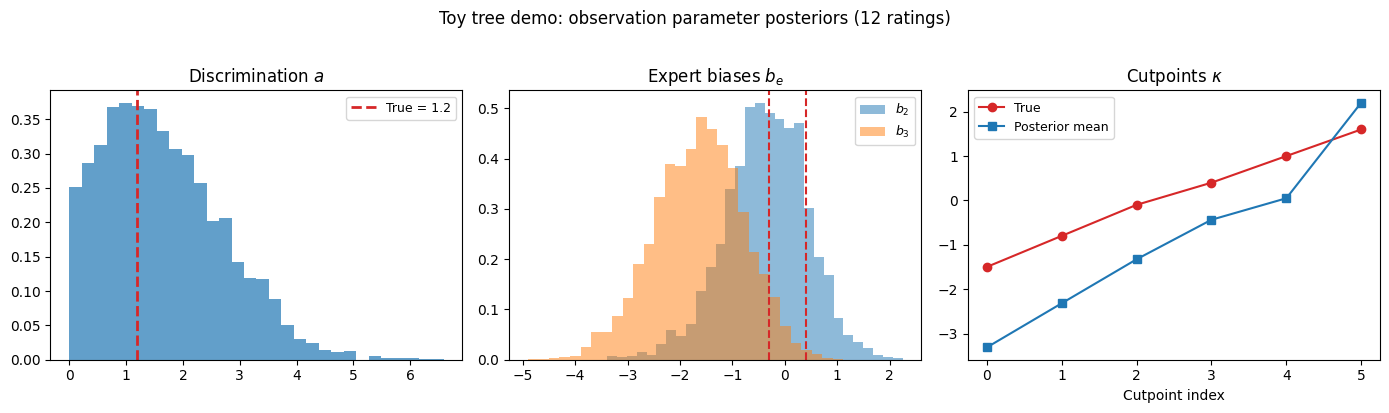

In [13]:
# Visual: observation parameter posteriors (wide -- expected with 12 ratings)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
a_draws = idata_tree.posterior["a"].values.flatten()
ax.hist(a_draws, bins=30, density=True, alpha=0.7)
ax.axvline(true_a_tree, color="C3", ls="--", lw=2, label=f"True = {true_a_tree}")
ax.set_title("Discrimination $a$")
ax.legend(fontsize=9)

ax = axes[1]
for i in range(n_experts - 1):
    draws = idata_tree.posterior["b_free"].sel(b_free_dim_0=i).values.flatten()
    ax.hist(draws, bins=30, density=True, alpha=0.5, label=f"$b_{{{i + 2}}}$")
    ax.axvline(true_b_tree[i + 1], color="C3", ls="--", lw=1.5)
ax.set_title("Expert biases $b_e$")
ax.legend(fontsize=9)

ax = axes[2]
ax.plot(true_kappa_tree, "C3o-", label="True", ms=6)
k_post = idata_tree.posterior["kappa"].mean(dim=("chain", "draw")).values
ax.plot(k_post, "C0s-", label="Posterior mean", ms=6)
ax.set_xlabel("Cutpoint index")
ax.set_title("Cutpoints $\\kappa$")
ax.legend(fontsize=9)

plt.suptitle("Toy tree demo: observation parameter posteriors (12 ratings)", y=1.02)
plt.tight_layout()
plt.show()

---

## 6. Integration sketch

### Minimal conceptual swap point

**Replace** `_create_indicator_variable` (lines 289--322):
- Currently: averages expert probabilities, draws random 0/1, feeds single `pm.Bernoulli(observed=...)`
- New: takes all expert ratings for this indicator, computes marginalised ordinal probit log-likelihood via `pm.Potential`

### Required engineering changes

**`build_model`:** Add model-level shared parameters ($a$, $b_e$, $\kappa$) defined once, not per-indicator.

**`set_observation_context` / `get_random_system`:** Currently selects one random expert position. New version needs to pass **all** expert ratings and expert indices per indicator.

**`ResultsManager`:** Currently looks for named Bernoulli variables in the trace (e.g. `{name}_bern`). The new model contributes leaf evidence via `pm.Potential`, which does not create named trace variables. Posterior extraction and reporting need updating.

**`main()` control flow:** The single-observation-position logic (`position`, `observation_name`) no longer applies. The model uses all observations for the selected system.

### What stays the same
- The tree structure above the indicators (features, stance, Beta priors, support/demandingness mapping)
- `DataFetcher` and the API interface
- The hierarchical Beta-Bernoulli construction for features and sub-features

---

## 7. Current GWT data: audit summary

| Metric | Value |
|---|---|
| Experts | 6 |
| Systems | 4 (LLMs, Chicken, ELIZA, Human) |
| Indicators | 49 |
| Valid observations | 379 |
| Response format | Probability on [0, 1] (not Likert) |
| Exact 0.0 | 74 (19.5%) |
| Exact 1.0 | 88 (23.2%) |
| Distinct values | 26 (quasi-discrete, ~0.05 increments) |

**Expert x system coverage:**

| Expert | LLMs | Chicken | ELIZA | Human | Cross-system? |
|---|---|---|---|---|---|
| Expert A | 40 | - | - | - | No |
| Expert B | 50 | - | 50 | 50 | **Yes** |
| Expert C | 48 | - | - | - | No |
| Expert D | - | 47 | - | - | No |
| Expert E | 48 | - | - | - | No |
| Expert F | - | 46 | - | - | No |

**Implications:**
- Only one expert has cross-system overlap. They are the sole rater for Human and ELIZA.
- Expert-specific discrimination and expert-specific cutpoints are **not identifiable** with this data.
- Shared $a$ + shared $\kappa$ + per-expert bias $b_e$ (with informative priors) is the ceiling.
- The current data is probability judgements, not Likert ratings. The ordered probit model is designed for **future survey data** using a 7-point scale.

---

## 8. Real-data demo: GWT indicators for LLMs

The current GWT data contains expert probability judgements on [0, 1], not Likert ratings. To test the observation model on real data, we convert these probabilities to a 7-point ordinal scale.

**Caveat:** This is converted data, not native Likert responses. The binning is a modelling choice. The purpose is a feasibility demo -- does the observation model extract a coherent latent structure from real expert ratings?

**Conversion scheme:**

| Category | Probability range | Interpretation |
|---|---|---|
| 0 | [0.00, 0.05) | Very strongly disagree |
| 1 | [0.05, 0.20) | Strongly disagree |
| 2 | [0.20, 0.40) | Disagree |
| 3 | [0.40, 0.60) | Neutral |
| 4 | [0.60, 0.80) | Agree |
| 5 | [0.80, 0.95) | Strongly agree |
| 6 | [0.95, 1.00] | Very strongly agree |

System: 2024 Leading Chat LLMs
Experts: 4, Indicators: 49
Valid observations: 186


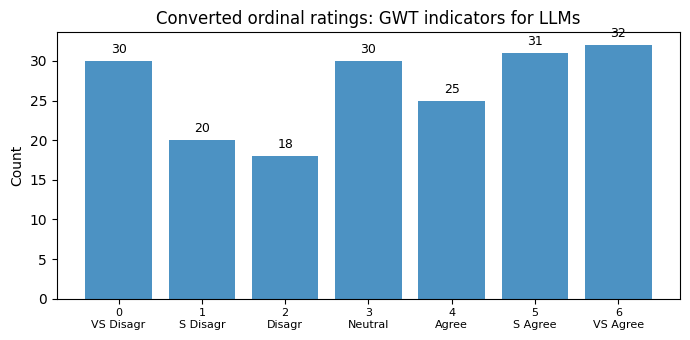

In [14]:
# --- Extract and convert GWT LLM data ---
import json

with open("../data_cache.json") as f:
    all_data = json.load(f)

gwt = all_data[0]
target_system = "2024 Leading Chat LLMs"


def prob_to_ordinal(p: float) -> int:
    """Convert probability to 7-point ordinal (0-indexed)."""
    if p < 0.05:
        return 0
    elif p < 0.20:
        return 1
    elif p < 0.40:
        return 2
    elif p < 0.60:
        return 3
    elif p < 0.80:
        return 4
    elif p < 0.95:
        return 5
    else:
        return 6


# Collect indicator data
records = []
indicator_names = []


def collect_indicators(node):
    if "observations" in node and target_system in node["observations"]:
        sys_data = node["observations"][target_system]
        for i, val in enumerate(sys_data["values"]):
            if val != -1 and val != "-1":
                records.append(
                    {
                        "indicator": node["name"],
                        "expert": sys_data["names"][i],
                        "value": float(val),
                        "ordinal": prob_to_ordinal(float(val)),
                    }
                )
        if node["name"] not in indicator_names:
            indicator_names.append(node["name"])
    for child in node.get("evidencers", []):
        collect_indicators(child)


collect_indicators(gwt)

expert_names_real = sorted(set(r["expert"] for r in records))
expert_to_idx = {e: i for i, e in enumerate(expert_names_real)}
ind_to_idx = {ind: i for i, ind in enumerate(indicator_names)}

real_expert_idx = np.array([expert_to_idx[r["expert"]] for r in records])
real_ind_idx = np.array([ind_to_idx[r["indicator"]] for r in records])
real_ratings = np.array([r["ordinal"] for r in records])

n_real_experts = len(expert_names_real)
n_real_indicators = len(indicator_names)

print(f"System: {target_system}")
print(f"Experts: {n_real_experts}, Indicators: {n_real_indicators}")
print(f"Valid observations: {len(records)}")

# Category distribution
fig, ax = plt.subplots(figsize=(7, 3.5))
cat_labels = [
    "0\nVS Disagr",
    "1\nS Disagr",
    "2\nDisagr",
    "3\nNeutral",
    "4\nAgree",
    "5\nS Agree",
    "6\nVS Agree",
]
counts = [np.sum(real_ratings == k) for k in range(7)]
ax.bar(range(7), counts, alpha=0.8)
ax.set_xticks(range(7))
ax.set_xticklabels(cat_labels, fontsize=8)
ax.set_ylabel("Count")
ax.set_title("Converted ordinal ratings: GWT indicators for LLMs")
for i, c in enumerate(counts):
    ax.text(i, c + 1, str(c), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

In [15]:
# --- Fit: bottom-layer ordered probit on real GWT/LLM data ---
# Per-indicator z_j is unknown -> marginalise with shared prior q ~ Beta(1,1)
#
# To avoid PyTensor graph explosion from 49 separate Potentials,
# we vectorise: compute log-lik for all observations at once under z=0 and z=1,
# then aggregate per indicator.
K_real = 7

# Pre-compute per-indicator observation slices
ind_slices = []
for j in range(n_real_indicators):
    mask = real_ind_idx == j
    if np.any(mask):
        ind_slices.append(np.where(mask)[0])
    else:
        ind_slices.append(None)

with pm.Model() as real_model:
    # Observation model parameters (shared)
    a = pm.HalfNormal("a", sigma=2.0)
    b_free = pm.Normal("b_free", mu=0.0, sigma=2.0, shape=n_real_experts - 1)
    b = pt.concatenate([pt.zeros(1), b_free])
    kappa = pm.Normal(
        "kappa",
        mu=0.0,
        sigma=2.0,
        shape=K_real - 1,
        transform=pm.distributions.transforms.ordered,
        initval=np.linspace(-1.5, 1.5, K_real - 1),
    )
    q = pm.Beta("q", alpha=1.0, beta=1.0)

    # Compute log-probs for ALL observations at once under z=0 and z=1
    def _all_obs_logp(eta_shift):
        eta = b[real_expert_idx] + eta_shift
        c_minus_eta = kappa[None, :] - eta[:, None]
        cum_probs = pt.erfc(-c_minus_eta / pt.sqrt(2.0)) / 2.0
        zeros = pt.zeros((cum_probs.shape[0], 1))
        ones = pt.ones((cum_probs.shape[0], 1))
        cum_full = pt.concatenate([zeros, cum_probs, ones], axis=1)
        cat_probs = cum_full[:, 1:] - cum_full[:, :-1]
        cat_probs = pt.clip(cat_probs, 1e-12, 1.0)
        return pt.log(cat_probs[pt.arange(len(real_ratings)), real_ratings])

    log_p_z0 = _all_obs_logp(0.0)  # (N,)
    log_p_z1 = _all_obs_logp(a)  # (N,)

    # Aggregate per indicator and marginalise
    total_log_lik = pt.zeros(())
    for j in range(n_real_indicators):
        if ind_slices[j] is None:
            continue
        idx = ind_slices[j]
        ll_z0_j = pt.sum(log_p_z0[idx])
        ll_z1_j = pt.sum(log_p_z1[idx])
        log_mix = pt.logaddexp(
            pt.log(1 - q + 1e-12) + ll_z0_j,
            pt.log(q + 1e-12) + ll_z1_j,
        )
        total_log_lik = total_log_lik + log_mix

    pm.Potential("leaf_lik", total_log_lik)

with real_model:
    idata_real = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        random_seed=42,
        target_accept=0.95,
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b_free, kappa, q]


/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 22 seconds.


In [19]:
# --- Results: observation parameters ---
print("=== Observation parameters ===")
print(f"  a (discrimination): {idata_real.posterior['a'].mean().item():.3f}")
print(f"  q (base rate):      {idata_real.posterior['q'].mean().item():.3f}")

b_post = idata_real.posterior["b_free"].mean(dim=("chain", "draw")).values
print(f"\n  Expert biases (relative to Expert A = 0):")
for i, e in enumerate(expert_names_real[1:]):
    print(f"    Expert {chr(66 + i)}: {b_post[i]:+.3f}")

k_post = idata_real.posterior["kappa"].mean(dim=("chain", "draw")).values
print(f"\n  Cutpoints: {np.round(k_post, 3)}")

print("\n=== Diagnostics ===")
print(az.summary(idata_real, var_names=["a", "q", "b_free", "kappa"]))

=== Observation parameters ===
  a (discrimination): 2.035
  q (base rate):      0.246

  Expert biases (relative to Expert A = 0):
    Expert B: -0.160
    Expert C: +0.161
    Expert D: +0.276

  Cutpoints: [-0.762 -0.321  0.024  0.574  1.069  1.889]

=== Diagnostics ===
            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
a          2.035  0.270   1.520    2.495      0.005    0.008    3752.0   
q          0.246  0.072   0.108    0.376      0.001    0.001    4154.0   
b_free[0] -0.160  0.223  -0.578    0.256      0.004    0.003    2605.0   
b_free[1]  0.161  0.227  -0.258    0.598      0.005    0.003    2538.0   
b_free[2]  0.276  0.226  -0.124    0.721      0.004    0.003    3184.0   
kappa[0]  -0.762  0.188  -1.106   -0.400      0.004    0.003    2683.0   
kappa[1]  -0.321  0.187  -0.658    0.035      0.003    0.003    2874.0   
kappa[2]   0.024  0.190  -0.313    0.392      0.004    0.003    2872.0   
kappa[3]   0.574  0.199   0.200    0.941      0.004    0.003

In [17]:
# --- Per-indicator latent class posterior ---
# Compute P(z_j = 1 | data) for each indicator using posterior samples
a_samples = idata_real.posterior["a"].values.flatten()
q_samples = idata_real.posterior["q"].values.flatten()
b_free_samples = idata_real.posterior["b_free"].values.reshape(-1, n_real_experts - 1)
kappa_samples = idata_real.posterior["kappa"].values.reshape(-1, K_real - 1)

n_samples = len(a_samples)
indicator_z_probs = np.zeros(n_real_indicators)

for j in range(n_real_indicators):
    mask = real_ind_idx == j
    if not np.any(mask):
        continue
    r_j = real_ratings[mask]
    e_j = real_expert_idx[mask]

    # Average P(z=1|data) over posterior samples
    z1_probs = np.zeros(n_samples)
    for s in range(0, n_samples, 10):  # subsample for speed
        a_s = a_samples[s]
        q_s = q_samples[s]
        b_s = np.concatenate([[0.0], b_free_samples[s]])
        k_s = kappa_samples[s]

        ll_z0 = sum(
            np.log(ordinal_probs(k_s, b_s[e] + 0.0)[r] + 1e-30)
            for e, r in zip(e_j, r_j)
        )
        ll_z1 = sum(
            np.log(ordinal_probs(k_s, b_s[e] + a_s)[r] + 1e-30)
            for e, r in zip(e_j, r_j)
        )

        log_num = np.log(q_s + 1e-30) + ll_z1
        log_den = np.logaddexp(np.log(1 - q_s + 1e-30) + ll_z0, log_num)
        z1_probs[s // 10] = np.exp(log_num - log_den)

    indicator_z_probs[j] = np.mean(z1_probs[: n_samples // 10])

# Sort and display
sorted_idx = np.argsort(indicator_z_probs)[::-1]
print("=== Indicators ranked by P(high-rating latent class) ===")
print(f"{'Indicator':<50s} {'P(z=1)':>8s}  {'Mean rating':>11s}")
print("-" * 72)
for idx in sorted_idx:
    mask = real_ind_idx == idx
    mean_r = real_ratings[mask].mean()
    print(
        f"{indicator_names[idx]:<50s} {indicator_z_probs[idx]:>8.3f}  {mean_r:>11.2f}"
    )

=== Indicators ranked by P(high-rating latent class) ===
Indicator                                            P(z=1)  Mean rating
------------------------------------------------------------------------
Dedicated Speech Systems                              1.000         6.00
Number of Layers                                      1.000         6.00
Probe-Detectable Themes                               1.000         6.00
Logical Inference                                     1.000         6.00
Diversity of Tasks                                    0.999         5.75
Priming Enhancement                                   0.989         5.50
Stable Personality                                    0.969         4.75
Concept-Specific Ablation Effects                     0.875         5.00
Variability of Responses to Stimuli                   0.802         5.00
Information Transfer Architecture                     0.669         5.00
Learning Transfer                                     0.629        

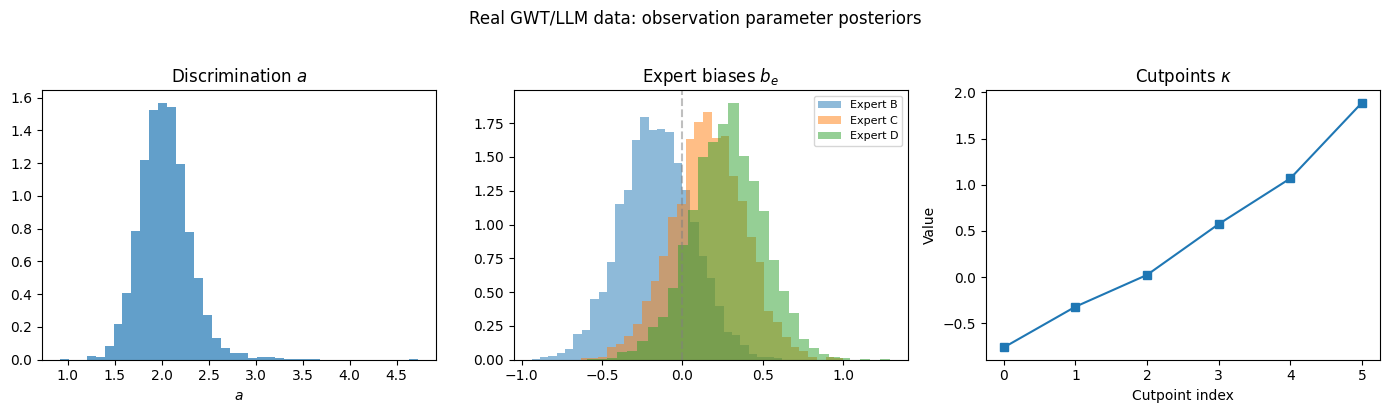

In [18]:
# --- Visual: observation parameter posteriors ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ax.hist(a_samples, bins=40, density=True, alpha=0.7)
ax.set_title("Discrimination $a$")
ax.set_xlabel("$a$")

ax = axes[1]
for i in range(n_real_experts - 1):
    draws = idata_real.posterior["b_free"].sel(b_free_dim_0=i).values.flatten()
    ax.hist(draws, bins=30, density=True, alpha=0.5, label=f"Expert {chr(66 + i)}")
ax.set_title("Expert biases $b_e$")
ax.axvline(0, color="grey", ls="--", alpha=0.5)
ax.legend(fontsize=8)

ax = axes[2]
ax.plot(k_post, "C0s-", ms=6)
ax.set_xlabel("Cutpoint index")
ax.set_ylabel("Value")
ax.set_title("Cutpoints $\\kappa$")

plt.suptitle("Real GWT/LLM data: observation parameter posteriors", y=1.02)
plt.tight_layout()
plt.show()

---

## 9. Reference systems as soft ground truth

The model above treats all 49 indicators identically -- no external information about which should be present. But we have data for **reference systems** where we have strong prior beliefs:

- **Human:** very likely conscious → indicators likely present ($z \approx 1$)
- **ELIZA:** very likely not conscious → indicators likely absent ($z \approx 0$)

Both are rated by one expert (Expert B) across all 49 indicators. By including this data with soft anchors, we directly calibrate $a$, $b_e$, and $\kappa$ because the latent states are near-certain. No two-stage process -- everything fits in one joint model.

This is Arvo's proposed approach: assign graded credences (e.g., human at 0.99999, thermostat at the opposite extreme) rather than hard labels.

In [ ]:
# --- Extract data for all three systems ---
systems_to_use = {
    "Human": 0.99999,  # soft anchor: z ≈ 1
    "ELIZA": 0.00001,  # soft anchor: z ≈ 0
    "2024 Leading Chat LLMs": None,  # unknown -- this is what we want to infer
}

all_records = []
all_indicator_names = []

for system, anchor in systems_to_use.items():

    def collect_system(node, sys=system, anc=anchor):
        if "observations" in node and sys in node["observations"]:
            sys_data = node["observations"][sys]
            for i, val in enumerate(sys_data["values"]):
                if val != -1 and val != "-1":
                    all_records.append(
                        {
                            "indicator": node["name"],
                            "expert": sys_data["names"][i],
                            "system": sys,
                            "anchor_q": anc,
                            "value": float(val),
                            "ordinal": prob_to_ordinal(float(val)),
                        }
                    )
            if node["name"] not in all_indicator_names:
                all_indicator_names.append(node["name"])
        for child in node.get("evidencers", []):
            collect_system(child, sys, anc)

    collect_system(gwt)

all_expert_names = sorted(set(r["expert"] for r in all_records))
all_expert_to_idx = {e: i for i, e in enumerate(all_expert_names)}
all_ind_to_idx = {ind: i for i, ind in enumerate(all_indicator_names)}

n_all_experts = len(all_expert_names)
n_all_indicators = len(all_indicator_names)

print(f"Total observations: {len(all_records)}")
print(f"Experts: {n_all_experts}, Indicators: {n_all_indicators}")
for sys in systems_to_use:
    n = sum(1 for r in all_records if r["system"] == sys)
    print(f"  {sys}: {n} obs")

In [ ]:
# --- Fit with reference system anchors ---
# Each (system, indicator) pair gets its own latent z.
# For Human: q ≈ 1. For ELIZA: q ≈ 0. For LLMs: q free.

# Build observation arrays
ref_expert_idx = np.array([all_expert_to_idx[r["expert"]] for r in all_records])
ref_ind_idx = np.array([all_ind_to_idx[r["indicator"]] for r in all_records])
ref_ratings = np.array([r["ordinal"] for r in all_records])
ref_systems = np.array([r["system"] for r in all_records])

# Group observations by (system, indicator)
from itertools import product

sys_ind_pairs = []
for sys in systems_to_use:
    for j in range(n_all_indicators):
        mask = (ref_systems == sys) & (ref_ind_idx == j)
        if np.any(mask):
            sys_ind_pairs.append(
                {
                    "system": sys,
                    "indicator": j,
                    "idx": np.where(mask)[0],
                    "anchor_q": systems_to_use[sys],
                }
            )

print(f"System-indicator pairs: {len(sys_ind_pairs)}")

with pm.Model() as ref_model:
    a = pm.HalfNormal("a", sigma=2.0)
    b_free = pm.Normal("b_free", mu=0.0, sigma=2.0, shape=n_all_experts - 1)
    b = pt.concatenate([pt.zeros(1), b_free])
    kappa = pm.Normal(
        "kappa",
        mu=0.0,
        sigma=2.0,
        shape=K_real - 1,
        transform=pm.distributions.transforms.ordered,
        initval=np.linspace(-1.5, 1.5, K_real - 1),
    )
    # Free q for LLM indicators
    q_llm = pm.Beta("q_llm", alpha=1.0, beta=1.0)

    # Vectorised log-probs for all observations
    def _ref_all_obs_logp(eta_shift):
        eta = b[ref_expert_idx] + eta_shift
        c_minus_eta = kappa[None, :] - eta[:, None]
        cum_probs = pt.erfc(-c_minus_eta / pt.sqrt(2.0)) / 2.0
        zeros = pt.zeros((cum_probs.shape[0], 1))
        ones = pt.ones((cum_probs.shape[0], 1))
        cum_full = pt.concatenate([zeros, cum_probs, ones], axis=1)
        cat_probs = cum_full[:, 1:] - cum_full[:, :-1]
        cat_probs = pt.clip(cat_probs, 1e-12, 1.0)
        return pt.log(cat_probs[pt.arange(len(ref_ratings)), ref_ratings])

    log_p_z0 = _ref_all_obs_logp(0.0)
    log_p_z1 = _ref_all_obs_logp(a)

    total_ll = pt.zeros(())
    for pair in sys_ind_pairs:
        idx = pair["idx"]
        ll_z0 = pt.sum(log_p_z0[idx])
        ll_z1 = pt.sum(log_p_z1[idx])

        if pair["anchor_q"] is not None:
            # Reference system: fixed q
            q_j = pair["anchor_q"]
        else:
            # LLM: free q
            q_j = q_llm

        log_mix = pt.logaddexp(
            pt.log(1 - q_j + 1e-12) + ll_z0,
            pt.log(q_j + 1e-12) + ll_z1,
        )
        total_ll = total_ll + log_mix

    pm.Potential("ref_lik", total_ll)

with ref_model:
    idata_ref = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        random_seed=42,
        target_accept=0.95,
    )

In [ ]:
# --- Results: compare with and without anchors ---
print("=== With reference system anchors (Human + ELIZA) ===")
print(f"  a:     {idata_ref.posterior['a'].mean().item():.3f}")
print(f"  q_llm: {idata_ref.posterior['q_llm'].mean().item():.3f}")
b_ref = idata_ref.posterior["b_free"].mean(dim=("chain", "draw")).values
print(f"  b_free: {np.round(b_ref, 3)}")
k_ref = idata_ref.posterior["kappa"].mean(dim=("chain", "draw")).values
print(f"  kappa:  {np.round(k_ref, 3)}")

print("\n=== Without anchors (Section 8, LLMs only) ===")
print(f"  a:     {idata_real.posterior['a'].mean().item():.3f}")
print(f"  q:     {idata_real.posterior['q'].mean().item():.3f}")
b_no = idata_real.posterior["b_free"].mean(dim=("chain", "draw")).values
print(f"  b_free: {np.round(b_no, 3)}")
k_no = idata_real.posterior["kappa"].mean(dim=("chain", "draw")).values
print(f"  kappa:  {np.round(k_no, 3)}")

print("\n=== Diagnostics ===")
print(az.summary(idata_ref, var_names=["a", "q_llm", "b_free", "kappa"]))

**Interpretation:**

- **$a \approx 3.1$ (up from 2.0 without anchors):** The reference systems sharpen the discrimination estimate. A large $a$ means the model finds a clear separation between how experts rate indicators that are present vs absent -- the two latent classes produce very different rating patterns.
- **$q_{\text{llm}} \approx 0.14$ (down from 0.25):** With calibration from Human ($z \approx 1$) and ELIZA ($z \approx 0$), only ~14% of GWT indicators are assigned to the "present" class for LLMs. The anchors tighten and shift this estimate because the model now has a calibrated sense of what "present" and "absent" ratings actually look like.
- **Expert B bias $\approx -0.75$:** Now clearly identified as harsher than Expert A, because the model can separate expert bias from system effects via cross-system data (Expert B rates Human, ELIZA, and LLMs).

---

## 10. Survey design implications

The model's identifiability and precision depend directly on how future data is collected. Key requirements:

**Cross-system expert overlap.** The current data has almost no overlap -- most experts rate only one system. Without overlap, expert biases $b_e$ are confounded with system effects. Future surveys should have each expert rate **at least two systems** (e.g., the target system plus one reference system).

**Reference system inclusion.** Including systems with strong prior credences (human, thermostat/ELIZA) provides near-ground-truth $z$ values that calibrate $a$, $b_e$, and $\kappa$. Every expert should rate at least one "clearly conscious" and one "clearly not conscious" reference system. This is the single most impactful design choice for identifiability.

**Minimum experts per indicator.** With shared $a$ and shared $\kappa$, even 3--4 experts per indicator is workable (all ratings inform the shared parameters). With expert-specific discrimination $a_e$, more experts per indicator are needed -- likely 5+ to begin separating individual sensitivity from noise.

**Rating scale.** A 7-point Likert scale is well-suited: enough categories to capture variation without overwhelming respondents. The ordered probit model does not assume equal spacing, so verbal anchors (e.g., "strongly disagree" to "strongly agree") are sufficient.

**Summary of design recommendations:**

| Design choice | Minimum | Ideal |
|---|---|---|
| Experts per indicator per system | 3 | 5+ |
| Systems per expert | 2 (target + 1 reference) | 3+ (target + 2 references) |
| Reference systems | 1 high + 1 low | 2 high + 2 low |
| Rating scale | 5-point | 7-point |

---

## 11. Planned extensions

**Expert-specific discrimination.** The current model uses shared $a$ across all indicators. With sufficient data per indicator (5+ experts), a hierarchical extension allows each indicator its own discrimination:

$$a_j \sim \text{LogNormal}(\mu_a, \sigma_a)$$

This pools information across indicators while allowing some to be more discriminating than others. The hierarchical prior regularises when per-indicator data is thin.

**Expert-specific cutpoints.** If experts use the rating scale differently (not just shifted, but with different category widths), hierarchical cutpoints per expert can capture this:

$$\kappa_k^{(e)} \sim \text{Normal}(\bar{\kappa}_k, \tau_\kappa)$$

This follows the progression in Betancourt (2024): shared cutpoints → independent cutpoints → hierarchical cutpoints.

**Arvo's parameterisation.** The model in Arvo's notes uses $\delta_k^{(0)}$ and $\delta_k^{(1)}$ -- expert-specific location parameters for both $z=0$ and $z=1$. The equivalence to the current model is:

| Arvo's notation | This notebook | Relationship |
|---|---|---|
| $\delta_k^{(0)}$ | $b_e$ | Expert baseline when indicator absent |
| $\delta_k^{(1)}$ | $b_e + a$ | Expert baseline when indicator present |
| $\delta_k^{(1)} - \delta_k^{(0)}$ | $a$ | Shared discrimination (first pass) |
| $\gamma_1, \ldots, \gamma_6$ | $\kappa_1, \ldots, \kappa_6$ | Cutpoints |

Arvo's version is the natural target once data supports expert-specific discrimination ($a_e = \delta_e^{(1)} - \delta_e^{(0)}$ varies by expert).